## PHYS-467 Machine Learning for Physicists. Exercise session 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import sklearn.linear_model as linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import sklearn.preprocessing as preprocessing

# Exercise 1: Linear Regression in 1D

**Question 1.a)** Write a function that creates one dimensional linear data and add a gaussian noise i.e $y = a \times x + \varepsilon$

In [2]:
def generate_data(n_data, coefficient, variance):
    X = np.random.normal(size=(n_data,))
    y = X * coefficient + np.sqrt(variance) * np.random.normal(size=(n_data,))

    return X.reshape((-1, 1)), y

In [3]:
coefficient = 3
n_data      = 10
X, y = generate_data(n_data, coefficient, 0.5)
X.shape

(10, 1)

**Question 1.b)** Generate and plot some data (X, Y), along with the noiseless function $y = a \times x$

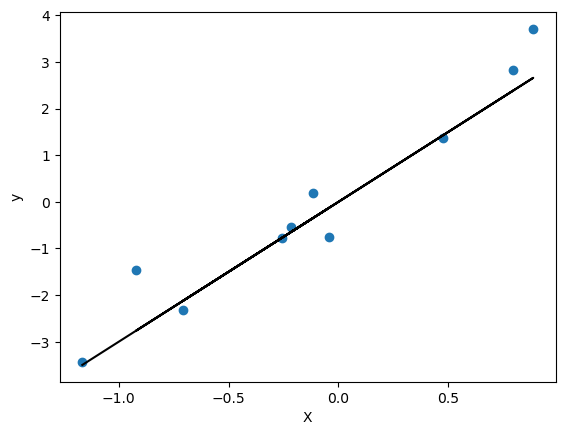

In [4]:
# Plot the training data

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y');

# ground truth 
plt.plot(X, coefficient * X, c='k')

**Question 2** Write a function to compute the least-square regression using the closed form seen in class.
Use this function on the  training data generated previously.

In [5]:
# Write a function to compute the linear-regression predictor in close form

def linear_regression(X, y):
    """
    arguments:
        - X : data matrix
        - y : output
    returns:
        - w : the least square estimator
    """
    lambda_ = 1.0
    X = np.concatenate((X, np.ones((len(X), 1))), axis=1) # Add column for bias
    w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return w

In [6]:
# Print the predicted weights (coefficient + bias)

w = linear_regression(X, y)
w

array([3.08861538, 0.27219391])

**Question 3** Generate a grid of points and apply your predictor on this grid. Plot it along your training set.

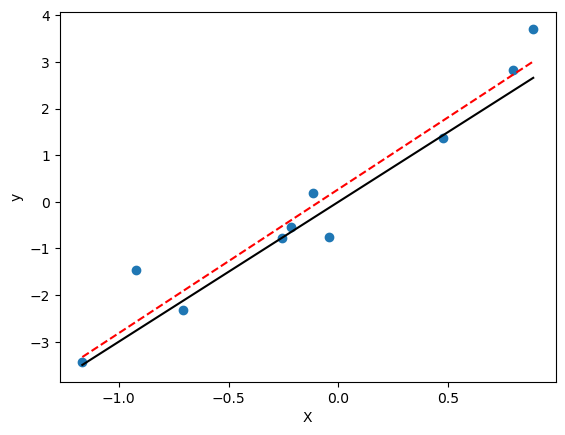

In [7]:
# Plot the training points and the predictor evaluated on a set of test points

X_test = np.linspace(np.min(X), np.max(X), 10)
y_test_pred = w[0] * X_test + w[1]

plt.scatter(X, y)
plt.plot(X_test, coefficient * X_test, 'k')
plt.plot(X_test, y_test_pred, 'r--')
plt.xlabel('X')
plt.ylabel('y');

**Question 4** Repeat the same with `LinearRegression` of the module [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Check that the coefficients are the same.

In [8]:
# Repeat with Scikit-learn

linear_regression_sk = LinearRegression()
linear_regression_sk.fit(X, y)
print('sklearn : ', linear_regression_sk.coef_, linear_regression_sk.intercept_)
print('w : ', w)

sklearn :  [3.08861538] 0.27219390662788406
w :  [3.08861538 0.27219391]


# Exercise 2: Polynomial Regression, Underfitting & Overfitting

**Question 1** Generate _noiseless_ points $x_1, ... x_n$ with few samples (say $5 \leqslant n \leqslant 10$) and $y_i = x_i^2$. Using [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) from sklearn, fit polynomials of varying degrees $d$ on your training data.

a) Plot the different polynomials obtained. What do you observe ? 


In [9]:
def generate_data(polynome, bruit_std, n):
    """
    arguments:
        - polynome  : list of coefficients representing the polynom (polynome[i] multiplies X^i)
        - bruit_std : standard deviation of the gaussian noise
        - n         : number of data points
    returns: 
        - (X, y)    : list of n points with y = P(x) + gaussian noise
    """    
    degree  = len(polynome) - 1
    samples = np.random.uniform(-2, 2, size=n)
    xs      = np.copy(samples)
    samples = np.ones((n, degree + 1)).T * samples
    powers  = np.power(samples.T, np.arange(0, degree + 1, 1))
    return xs, np.sum(powers * polynome, axis = 1) + np.random.normal(0, bruit_std, size=n)

In [62]:
n       = 5
bound   = 3

# function y = x^2
polynom = np.array( [0, 0, 1] )

np.random.seed(10)

# first start with noiseless data
noise = 0
xs, ys   = generate_data(polynom, noise, n)

Degree 1 : training error is 0.6193501416587561
Degree 2 : training error is 0.08212719925705753
Degree 5 : training error is 0.07584758396496136
Degree 8 : training error is 0.06504549253075778
Degree 10 : training error is 0.06347576255298575


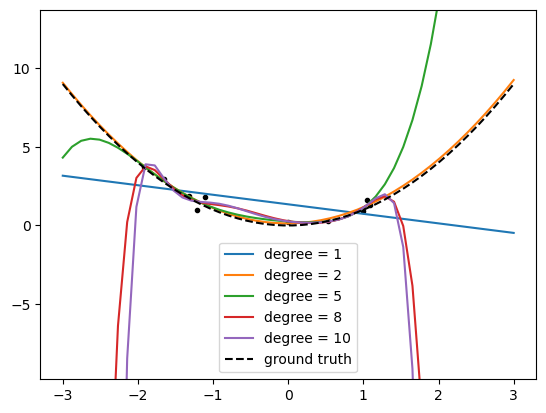

In [72]:
# Fit the data

x_grid = np.linspace(-bound, bound, 50)

degrees = [1, 2, 5, 8, 10]
coefs = []


for d in degrees:
    poly     = preprocessing.PolynomialFeatures(d)
    xs_trans = poly.fit_transform(xs.reshape(-1, 1))
    x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
    lr = linear_model.Ridge(alpha = 0.01, fit_intercept=False).fit(xs_trans, ys)
    y_pred = xs_trans @ lr.coef_
    coefs.append(lr.coef_)
    plt.plot(x_grid, x_grid_trans @ lr.coef_, label=f'degree = {d}')
    print(f'Degree {d} : training error is {mean_squared_error(ys, y_pred)}')

plt.plot(x_grid,x_grid**2, 'k--',  label='ground truth')
plt.scatter(xs, ys, marker='.', c='k')
plt.ylim(np.min(ys) - 10, np.max(ys) + 10)
plt.legend()

**Question 2** Now, generate _noisy_ quadratic data (i.e $y = x^2 + \varepsilon$) and fit again polynoms of various degrees. Sample a large test set and plot both the training and test error as a function of the degree $d$ of the predictor. Observe the underfitting and overfitting phenomenon.

Change the level of regularization ( the parameter `alpha` of the `Ridge` model) and observe what happens for higher-order polynomials. Do they still overfit ? 

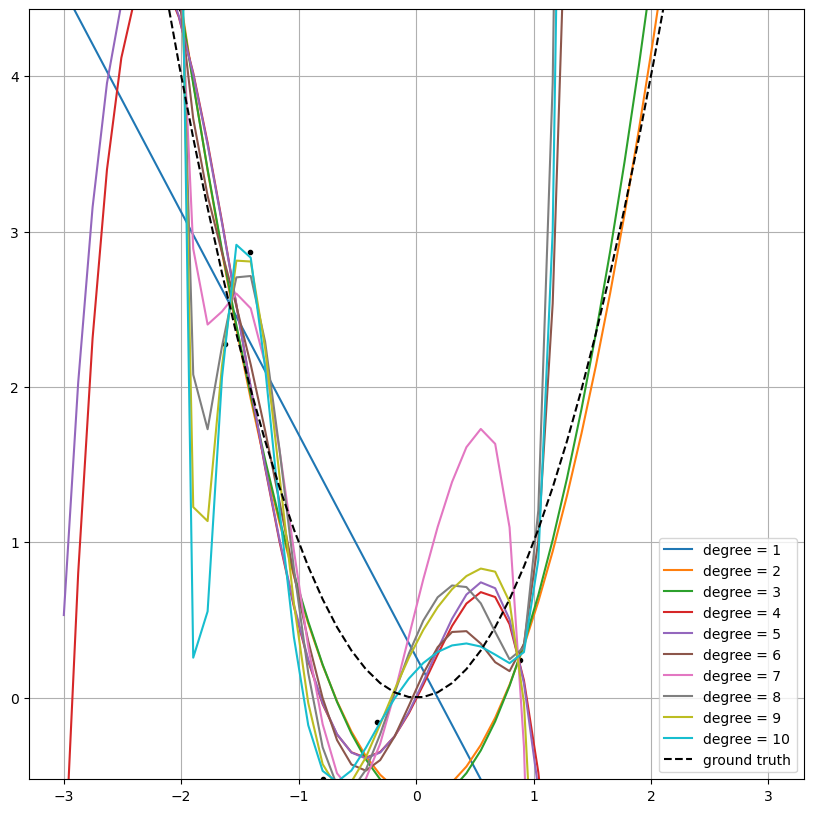

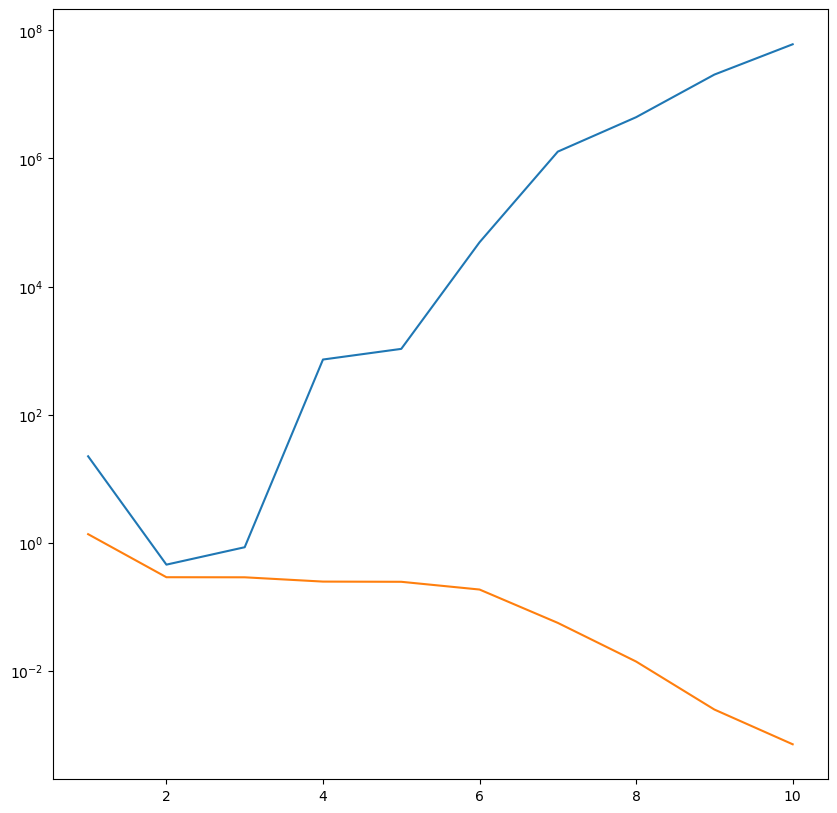

In [93]:
np.random.seed(1)
plt.figure(figsize=(10, 10))
plt.grid()

xs, ys  = generate_data(polynom, 0.5, 6)
y_true  = x_grid**2

degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

train_mses = []
test_mses = []

plt.scatter(xs, ys, c='k', marker='.')
for d in degrees:
    poly     = preprocessing.PolynomialFeatures(d)
    xs_trans = poly.fit_transform(xs.reshape(-1, 1))
    x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
    lr = linear_model.Ridge(alpha = 0.01, fit_intercept=False).fit(xs_trans, ys)
    y_pred = x_grid_trans @ lr.coef_
    plt.plot(x_grid, y_pred, label=f'degree = {d}')
    test_mses.append( mean_squared_error(y_true, y_pred) )
    #
    y_pred_train = xs_trans @ lr.coef_
    train_mses.append( mean_squared_error(ys, y_pred_train) )

plt.plot(x_grid, x_grid**2, 'k--', label='ground truth')
plt.legend()
plt.ylim(min(ys), max(ys))
plt.show()

plt.figure(figsize=(10, 10))
plt.grid()

plt.plot(degrees, test_mses)
plt.plot(degrees, train_mses)
plt.grid()
plt.yscale("log")
plt.show()

Add a $\ell_2$ regularisation term for the high-degree polynomial case. What happens ? Try to vary the strenth of the regularization.

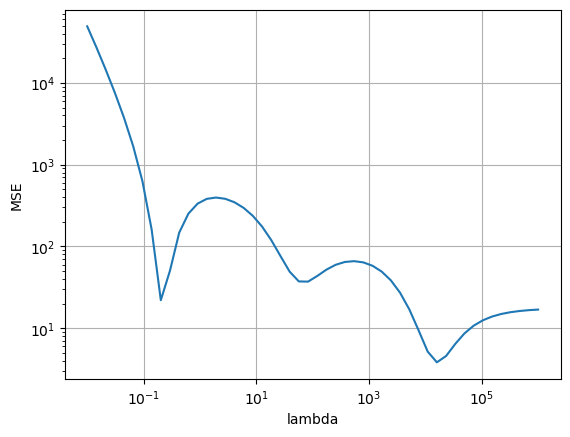

In [97]:
lambda_range = np.logspace(-2, 6, 50)
d = 6
ridge_mses = []

poly     = preprocessing.PolynomialFeatures(d)
xs_trans = poly.fit_transform(xs.reshape(-1, 1))
x_grid_trans = poly.fit_transform(x_grid.reshape((-1, 1)))
y_true = x_grid**2

for lambda_ in lambda_range:
    lr = linear_model.Ridge(alpha = lambda_, fit_intercept=False).fit(xs_trans, ys)
    y_pred = x_grid_trans @ lr.coef_
    ridge_mses.append(mean_squared_error(y_true, y_pred))

plt.semilogx(lambda_range, ridge_mses)
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid()
plt.show()


# Exercise 3: Real data

The superconductivity dataset [1] contains 81 chemical and molecular features extracted from 21263 superconductors along with the critical temperature (the label) in the 82nd column. The goal is to predict the critical temperature based on the 81 first features. If you are interested by the physical meaning of those 81 features, check out the original paper at https://arxiv.org/pdf/1803.10260.pdf !

[1] Hamidieh, Computational Materials Science, 2018

First, you need to download the dataset, in .csv format. You can find it here : https://archive.ics.uci.edu/dataset/464/superconductivty+data or on the Moodle.

Now, load the data. Since the format is .csv (data table), we used the Python module called pandas. If you are locally running the notebook, you need to indicate the path to it, e.g. "Downloads/train.csv". If you use colab, you have to upload it to colab (see the left hand side icon).

In [16]:
X=pd.read_csv("train.csv",index_col=None)

using .values() converts the table into a numpy array . Remember, the last column is the labels.

In [17]:
X_tot=X.values[:,:-1]
y_tot=X.values[:,-1]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_tot, y_tot, test_size=0.2)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.25)

Because different features correspond to different physical quantities and have different units, thus different magnitudes of numerical values, we preprocess the array.

In [19]:
scaler_X = preprocessing.StandardScaler().fit(X_train)
scaler_y = preprocessing.StandardScaler().fit(y_train.reshape(-1,1))

In [20]:
X_test=scaler_X.transform(X_test)
X_train=scaler_X.transform(X_train)
X_validation=scaler_X.transform(X_validation)


**Question 2** Fit a linear model on the training set, and compute the predictions $\hat y$ of your model. Compare them to the true values $y^*$, for example by printing the mean squared error.

In [21]:
# Perform linear regression on the training set

linear_regression_sk = LinearRegression()
linear_regression_sk.fit(X_train, y_train)

mse: 297.1277510895733


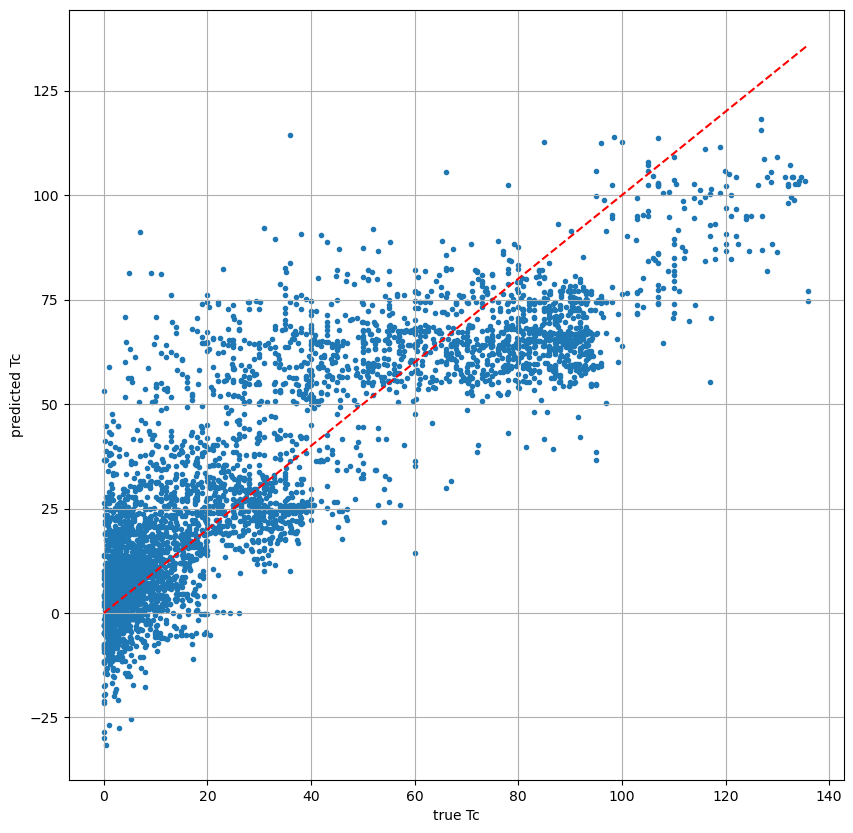

In [99]:
# Print the test error and plot the predicted prices vs the actual ones
plt.figure(figsize=(10, 10))
plt.grid()

y_pred = linear_regression_sk.predict(X_test)
print(f'mse: {mean_squared_error(y_test, y_pred)}')

plt.plot(np.linspace(np.min(y_test),np.max(y_test),100),np.linspace(np.min(y_test),np.max(y_test),100),ls="--",c="r")

plt.scatter(y_test, y_pred, marker='.')
plt.xlabel('true Tc')
plt.ylabel('predicted Tc');

**Question 3** Redo the question 2 while varying the size of the training set. For each size, compute the training and test error. How do they vary as a function of the training size ? 
As we do not regularize the model, we take sizes of the training set bigger than the dimension, otherwise the matrix is not invertible.

Observe that the train error is growing while the test error is going down, test error > train error, the curves are converging

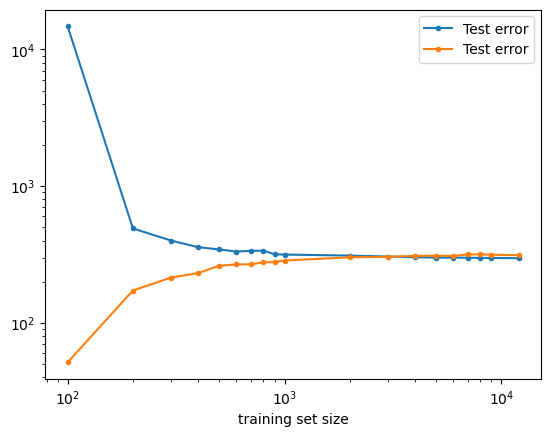

In [101]:
trainset_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 12000]

train_errors = []
test_errors = []

linear_regression_sk = LinearRegression()

for n in trainset_sizes:

    linear_regression_sk.fit(X_train[:n], y_train[:n])

    y_train_pred = linear_regression_sk.predict(X_train[:n])
    train_errors.append(mean_squared_error(y_train[:n], y_train_pred))

    y_test_pred = linear_regression_sk.predict(X_test)
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# plt.plot(trainset_sizes, train_errors, label='Train error')
plt.plot(trainset_sizes, test_errors, marker='.', label='Test error')
plt.plot(trainset_sizes, train_errors, marker='.', label='Test error')
plt.xlabel('training set size')
plt.yscale("log")
plt.xscale("log")
plt.legend();


**Question 4** First, implement a function that generates _non-interactive_ polynomial features : for a degree $k$ and an input $x = x_1, ..., x_d$, generate $\tilde x = x_1, ..., x_1^k, x_2, ..., x_2^k, ... x_d^k$.
Then, run a linear regression on these polynomial features with different degrees $k$. 
Observe the under/overfitting phenomenon.

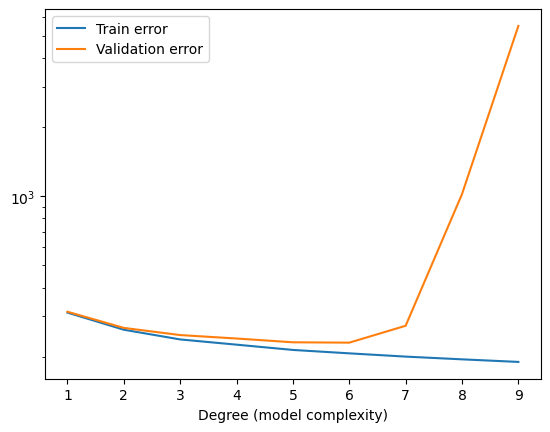

In [33]:
# Implement *non-interacting* polynomial-features regression (not present in sklearn, write a function using numpy) and vary the degree from 1 to 6. Plot the results.
# Comments: bias-variance tradeoff, U-shaped curve (while train error keeps going down, i.e. overfitting)

def non_interacting_polyfeat(X, k):
    """
    arguments: 
        - X : n x d matrix, where each row is a data sample
        - k : degree of the desired polynomial features
    returns: 
        - X2 : n x (dk) matrix containing the polynomial features
    """
    return np.concatenate([X**(i+1) for i in range(k)], axis=1)

train_errors = []
val_errors = []

ndegs = 10
for degree in range(1, ndegs):

    X_train_poly = non_interacting_polyfeat(X_train, degree)
    linear_regression_sk.fit(X_train_poly, y_train)

    y_train_pred_poly = linear_regression_sk.predict(X_train_poly)
    train_errors.append(mean_squared_error(y_train, y_train_pred_poly))

    y_val_pred_poly = linear_regression_sk.predict(non_interacting_polyfeat(X_validation, degree))
    val_errors.append(mean_squared_error(y_validation, y_val_pred_poly))

plt.semilogy(np.arange(1,ndegs), train_errors, label='Train error')
plt.semilogy(np.arange(1,ndegs), val_errors, label='Validation error')
plt.xlabel('Degree (model complexity)')
plt.legend();

**Question 5** From the previous question, pick a degree that you think is best, and add different regularisation strength $\lambda$ to the regression. Plot the training and test errors as a function of $\lambda$.

Best degree is  6


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.59675e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.59675e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.59675e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.59676e-17): result may not be accurate.
  return lina

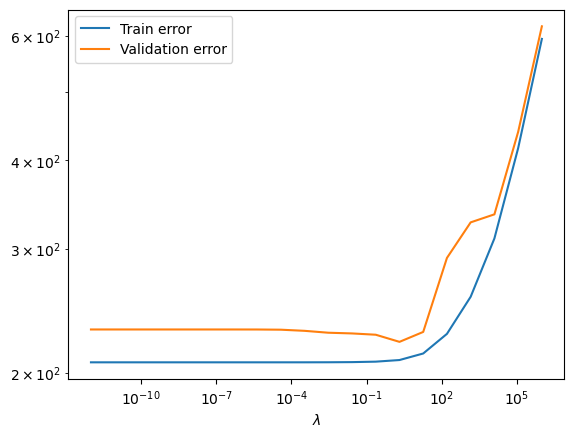

In [35]:
# Add different regularisers to the degree-6 model. Plot the results and find the best value.

best_degree = list(range(1, ndegs))[np.argmin(val_errors)]
print('Best degree is ', best_degree)

reg_strenghts = np.logspace(-12, 6, 20)

train_errors = []
val_errors_lambda = []

for reg_strenght in reg_strenghts:

    X_train_poly = non_interacting_polyfeat(X_train, k=best_degree)

    ridge_regression = Ridge(alpha=reg_strenght)
    ridge_regression.fit(X_train_poly, y_train)

    y_train_pred_poly = ridge_regression.predict(X_train_poly)
    train_errors.append(mean_squared_error(y_train, y_train_pred_poly))

    y_val_pred_poly = ridge_regression.predict(non_interacting_polyfeat(X_validation, k=best_degree))
    val_errors_lambda.append(mean_squared_error(y_validation, y_val_pred_poly))

plt.loglog(reg_strenghts, train_errors, label='Train error')
plt.loglog(reg_strenghts, val_errors_lambda, label='Validation error')
plt.xlabel('$\lambda$')
plt.legend();

In [87]:
lambda_opt = reg_strenghts[np.argmin(val_errors_lambda)]
print(f'Optimal lambda is {lambda_opt}, the validation error is {np.min(val_errors_lambda)}')

ridge_regression = Ridge(alpha=lambda_opt)
ridge_regression.fit(X_train_poly, y_train)

y_test_pred_poly = ridge_regression.predict(non_interacting_polyfeat(X_test, k=best_degree))
test_error = mean_squared_error(y_test, y_test_pred_poly)
print(f'Test error is {test_error}')

Optimal lambda is 4.281332398719396, the validation error is 236.95548523417793
Test error is 284.9860354188283
